In [ ]:

import math
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from dataclasses import dataclass

from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import make_pipeline


import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

ARTIFACTS_DIR = Path("artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
df = pd.read_csv('S12-hw-dataset.csv')
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [ ]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by='date')
print(f'Shape: {df.shape}')
print(f'Nans:\n {df.isna().sum()}')
print(f'Data range: {df['date'].max() - df['date'].min()}')


Shape: (4320, 2)
Nans:
 date      0
target    0
dtype: int64
Data range: 179 days 23:00:00


,count,mean,min,25%,50%,75%,max,std
date,4320,2025-03-31 23:30:00,2025-01-01 00:00:00,2025-02-14 23:45:00,2025-03-31 23:30:00,2025-05-15 23:15:00,2025-06-29 23:00:00,NaN
target,4320.0,135.60584,69.1,120.5375,135.835,150.625,210.1,21.384633


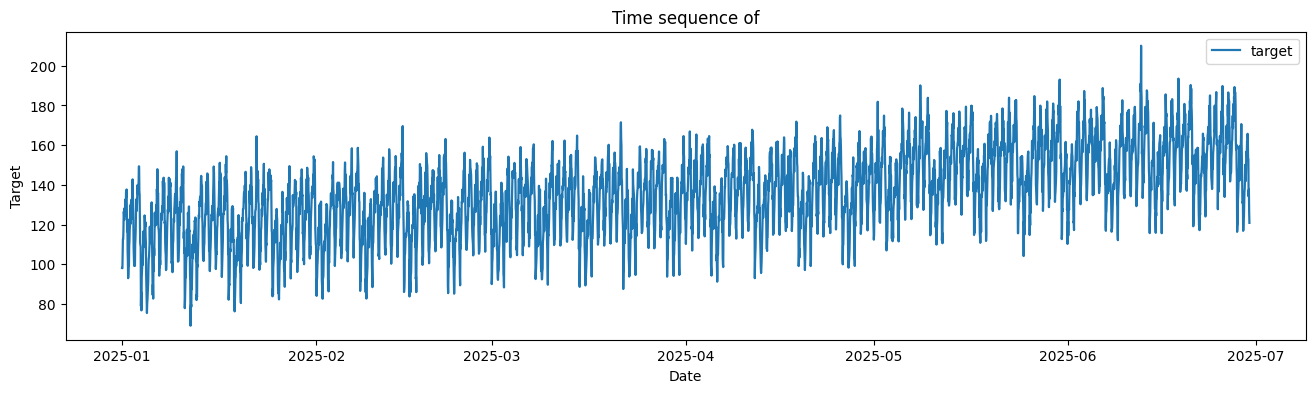

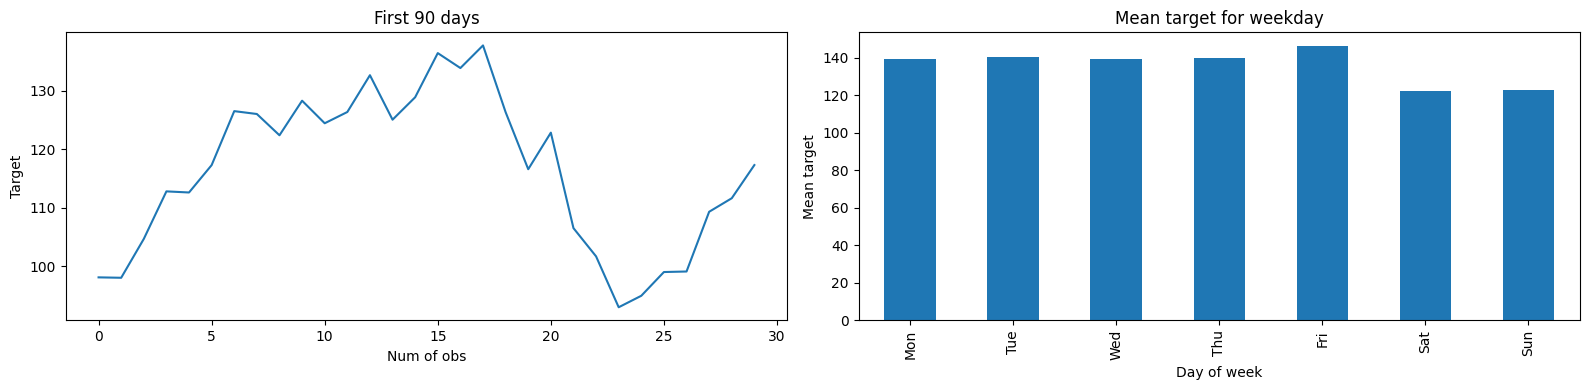

In [ ]:
display(df.describe(include="all").T)


fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df["date"], df["target"], lw=1.6, label="target")
ax.set_title("Time sequence of")
ax.set_xlabel("Date")
ax.set_ylabel("Target")
ax.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

df["target"].iloc[:30].plot(ax=axes[0], title="First 90 days")
axes[0].set_xlabel("Num of obs")
axes[0].set_ylabel("Target")

dow_order = [0, 1, 2, 3, 4, 5, 6]
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
(
    df.assign(dayofweek=df["date"].dt.dayofweek)
      .groupby("dayofweek")["target"].mean()
      .reindex(dow_order)
      .set_axis(dow_names)
      .plot(kind="bar", ax=axes[1], title="Mean target for weekday")
)
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("Mean target")

plt.tight_layout()
plt.show()

train: 2025-01-01 → 2025-05-06 | 3024 строк
val:   2025-05-07 → 2025-06-02 | 648 строк
test:  2025-06-03 → 2025-06-29 | 648 строк


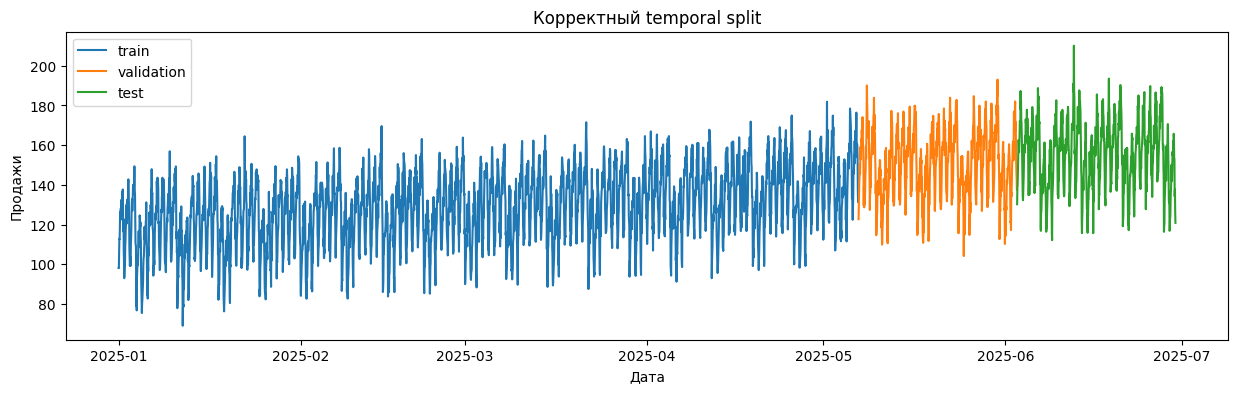

In [ ]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    assert math.isclose(cfg.train_frac + cfg.val_frac + cfg.test_frac, 1.0, rel_tol=1e-9)
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df['date'].min().date()} → {train_df['date'].max().date()} | {len(train_df)} строк")
print(f"val:   {val_df['date'].min().date()} → {val_df['date'].max().date()} | {len(val_df)} строк")
print(f"test:  {test_df['date'].min().date()} → {test_df['date'].max().date()} | {len(test_df)} строк")

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train_df["date"], train_df["target"], label="train")
ax.plot(val_df["date"], val_df["target"], label="validation")
ax.plot(test_df["date"], test_df["target"], label="test")
ax.set_title("Корректный temporal split")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажи")
ax.legend()
plt.savefig(FIGURES_DIR / "series_split.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['dayofweek'] = out['date'].dt.day_of_week

    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)

    return out

def add_lag_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    out = df.copy()

    for lag in [1, 7, 14]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)

    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()

    out["rolling_mean_14"] = out[target_col].shift(1).rolling(window=14).mean()
    out["rolling_std_14"] = out[target_col].shift(1).rolling(window=14).std()
    return out

features_df = add_calendar_features(df)
features_df = add_lag_features(features_df)
features_df = features_df.dropna().reset_index(drop=True)
features_df.head()


,date,target,dayofweek,dow_sin,dow_cos,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14
0,2025-01-01 14:00:00,128.87,2,0.974928,-0.222521,125.04,126.01,98.14,126.445714,3.275621,118.232143,11.300386
1,2025-01-01 15:00:00,136.40,2,0.974928,-0.222521,128.87,122.38,98.07,126.854286,3.388632,120.427143,10.008077
2,2025-01-01 16:00:00,133.85,2,0.974928,-0.222521,136.40,128.28,104.70,128.857143,4.318919,123.165000,8.559516
3,2025-01-01 17:00:00,137.71,2,0.974928,-0.222521,133.85,124.43,112.81,129.652857,4.691868,125.247143,7.152018
4,2025-01-01 18:00:00,126.32,2,0.974928,-0.222521,137.71,126.35,112.62,131.550000,4.907936,127.025714,6.913318


In [ ]:
feature_cols = [
    "dayofweek", "dow_sin", "dow_cos",
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7", 
    "rolling_mean_14", "rolling_std_14"
]

target_col = "target"

train_feat, val_feat, test_feat = temporal_split(features_df)
X_train = train_feat[feature_cols]
y_train = train_feat[target_col]

X_val = val_feat[feature_cols]
y_val = val_feat[target_col]

X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

print(f"Train shapes: {X_train.shape, y_train.shape}")
print(f"Val shapes: {X_val.shape, y_val.shape}")
print(f"Test shapes: {X_test.shape, y_test.shape}")

Train shapes: ((3014, 10), (3014,))
Val shapes: ((646, 10), (646,))
Test shapes: ((646, 10), (646,))


In [ ]:
#for metrics count

def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def evaluate_regression(y_true, y_pred, model_name: str) -> pd.DataFrame:
    return pd.DataFrame([{
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": mape(y_true, y_pred),
    }])


#naive baseline
val_pred_naive = val_feat["lag_1"].to_numpy()
test_pred_naive = test_feat["lag_1"].to_numpy()

#moving average
val_pred_ma7 = val_feat["rolling_mean_7"].to_numpy()
test_pred_ma7 = test_feat["rolling_mean_7"].to_numpy()

baseline_results_val = pd.concat([
    evaluate_regression(y_val, val_pred_naive, "Naive (lag_1)"),
    evaluate_regression(y_val, val_pred_ma7, "MovingAverage(7)"),
], ignore_index=True).sort_values("MAE")

print("Validation:")
display(baseline_results_val)

Validation:


,model,MAE,RMSE,MAPE_%
0,Naive (lag_1),6.443406,8.203532,4.394594
1,MovingAverage(7),12.723717,15.236326,8.828779


In [ ]:
pipeline = make_pipeline(StandardScaler(), Ridge())
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {'ridge__alpha': np.logspace(-3, 3, 20)}
grid = GridSearchCV(pipeline, param_grid, cv=tscv, scoring='neg_mean_absolute_error')
grid.fit(X_train, y_train)


best_alpha = grid.best_params_['ridge__alpha']
print(f"Best alpha: {best_alpha}")
print(f"Val MAE: {-grid.best_score_:.3f}")

Best alpha: 0.001
Val MAE: 5.645


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=grid.best_params_['ridge__alpha'])
ridge.fit(X_train_scaled, y_train)


val_pred_ridge = ridge.predict(X_val_scaled)
test_pred_ridge = ridge.predict(X_test_scaled)


val_results = pd.concat([
    baseline_results_val,
    evaluate_regression(y_val, val_pred_ridge, "Ridge"),  
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

print("Validation:")
display(val_results)


Validation:


,model,MAE,RMSE,MAPE_%
0,Naive (lag_1),6.443406,8.203532,4.394594
1,Ridge,6.679160,8.160595,4.447210
2,MovingAverage(7),12.723717,15.236326,8.828779


In [ ]:
window_size = 29
 
def make_windows(series_2d: np.ndarray, window_size: int):
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])     
        y.append(series_2d[i + window_size, 0])         
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32)  
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)          
test_scaled = scaler.transform(test_df[["target"]]).astype(np.float32)

X_train, y_train = make_windows(train_scaled, window_size)
X_val, y_val = make_windows(val_scaled, window_size)
X_test, y_test = make_windows(test_scaled, window_size)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (2995, 29, 1) y_train: (2995,)
X_val  : (619, 29, 1) y_val  : (619,)
X_test : (619, 29, 1) y_test : (619,)


In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)  

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

batch_size = 64  

train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)
test_ds = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)  
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)  
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)


xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape) 
print("Batch y:", yb.shape)  

Batch X: torch.Size([64, 29, 1])
Batch y: torch.Size([64])


In [ ]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size: int = 1, hidden_size: int = 48, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad() 
        preds = model(X_batch)  
        loss = criterion(preds, y_batch)  
        loss.backward()               
        optimizer.step() 

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))


def fit_model(model, train_loader, val_loader, epochs=12, lr=1e-3, device=device):
    criterion = nn.MSELoss() 
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) 

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict() 

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [ ]:
set_seed(42)
gru_model = GRUForecaster(hidden_size=64, num_layers=2).to(device)
print("GRU  params:", sum(p.numel() for p in gru_model.parameters()))
gru_history = fit_model(gru_model, train_loader, val_loader, epochs=30, lr=5e-4, device=device)

GRU  params: 37889
Epoch 01 | train_loss=0.7127 | val_loss=0.6229
Epoch 02 | train_loss=0.2956 | val_loss=0.2980
Epoch 03 | train_loss=0.1643 | val_loss=0.2117
Epoch 04 | train_loss=0.1531 | val_loss=0.2301
Epoch 05 | train_loss=0.1523 | val_loss=0.2393
Epoch 06 | train_loss=0.1494 | val_loss=0.2104
Epoch 07 | train_loss=0.1469 | val_loss=0.1997
Epoch 08 | train_loss=0.1459 | val_loss=0.2170
Epoch 09 | train_loss=0.1454 | val_loss=0.1995
Epoch 10 | train_loss=0.1434 | val_loss=0.2274
Epoch 11 | train_loss=0.1420 | val_loss=0.1753
Epoch 12 | train_loss=0.1411 | val_loss=0.2131
Epoch 13 | train_loss=0.1390 | val_loss=0.2122
Epoch 14 | train_loss=0.1347 | val_loss=0.1851
Epoch 15 | train_loss=0.1285 | val_loss=0.2592
Epoch 16 | train_loss=0.1217 | val_loss=0.2365
Epoch 17 | train_loss=0.1133 | val_loss=0.2207
Epoch 18 | train_loss=0.1093 | val_loss=0.1799
Epoch 19 | train_loss=0.1053 | val_loss=0.1831
Epoch 20 | train_loss=0.1058 | val_loss=0.1761
Epoch 21 | train_loss=0.1010 | val_loss=0

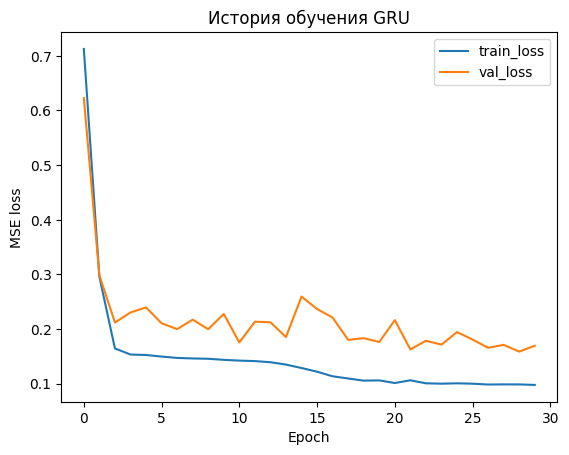

In [ ]:
fig, ax = plt.subplots()
ax.plot(gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["val_loss"], label="val_loss")
ax.set_title("История обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.savefig(FIGURES_DIR / "gru_learning_curves.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
@torch.no_grad()
def predict_model(model, loader, device):
    """
    Получает предсказания модели на батчах.
    Возвращает предсказания и истинные значения (в масштабированном пространстве).
    """
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()
        preds.append(outputs)
        targets.append(y_batch.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets


def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()

gru_val_pred_scaled, gru_val_true_scaled = predict_model(gru_model, val_loader, device)
val_true = inverse_scale(gru_val_true_scaled, scaler)
gru_val_pred = inverse_scale(gru_val_pred_scaled, scaler)


val_results = pd.concat([
    val_results,
    evaluate_regression(val_true, gru_val_pred, "GRU"),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)
val_results

,model,MAE,RMSE,MAPE_%
0,GRU,5.905569,7.630930,3.956915
1,Naive (lag_1),6.443406,8.203532,4.394594
2,Ridge,6.679160,8.160595,4.447210
3,MovingAverage(7),12.723717,15.236326,8.828779


In [ ]:
gru_test_pred_scaled, gru_test_true_scaled = predict_model(gru_model, test_loader, device)
test_true = inverse_scale(gru_test_true_scaled, scaler)
gru_test_pred = inverse_scale(gru_test_pred_scaled, scaler)
print(evaluate_regression(test_true, gru_test_pred, "GRU (on test data)"))

                model       MAE      RMSE    MAPE_%
0  GRU (on test data)  7.210696  9.175249  4.624162


In [ ]:
def save_runs_csv():
    runs_data = []

    runs_data.append({
        "experiment_id": "B1",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": 42,
        "split_summary": "70% train, 15% val, 15% test (temporal)",
        "window_size": "",
        "horizon": 1,
        "model_summary": "Naive forecast (lag_1)",
        "features_summary": "lag_1 only",
        "scaler": "",
        "optimizer": "",
        "lr": "",
        "epochs_trained": "",
        "best_val_mae": baseline_results_val[baseline_results_val['model'] == 'Naive (lag_1)']['MAE'].values[0],
        "best_val_rmse": baseline_results_val[baseline_results_val['model'] == 'Naive (lag_1)']['RMSE'].values[0],
        "best_val_mape": baseline_results_val[baseline_results_val['model'] == 'Naive (lag_1)']['MAPE_%'].values[0],
        "test_mae": "",
        "test_rmse": "",
        "test_mape": "",
        "notes": ""
    })
    
    runs_data.append({
        "experiment_id": "B2",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": 42,
        "split_summary": "70% train, 15% val, 15% test (temporal)",
        "window_size": 7,
        "horizon": 1,
        "model_summary": "Moving Average (window=7)",
        "features_summary": "rolling_mean_7",
        "scaler": "",
        "optimizer": "",
        "lr": "",
        "epochs_trained": "",
        "best_val_mae": baseline_results_val[baseline_results_val['model'] == 'MovingAverage(7)']['MAE'].values[0],
        "best_val_rmse": baseline_results_val[baseline_results_val['model'] == 'MovingAverage(7)']['RMSE'].values[0],
        "best_val_mape": baseline_results_val[baseline_results_val['model'] == 'MovingAverage(7)']['MAPE_%'].values[0],
        "test_mae": "",
        "test_rmse": "",
        "test_mape": "",
        "notes": ""
    })
    
    runs_data.append({
        "experiment_id": "B3",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": 42,
        "split_summary": "70% train, 15% val, 15% test (temporal)",
        "window_size": "",
        "horizon": 1,
        "model_summary": f"Ridge Regression (alpha={best_alpha})",
        "features_summary": "lag_1,7,14, rolling_mean_7/14, rolling_std_7/14, dayofweek features",
        "scaler": "StandardScaler",
        "optimizer": "",
        "lr": "",
        "epochs_trained": "",
        "best_val_mae": val_results[val_results['model'] == 'Ridge']['MAE'].values[0],
        "best_val_rmse": val_results[val_results['model'] == 'Ridge']['RMSE'].values[0],
        "best_val_mape": val_results[val_results['model'] == 'Ridge']['MAPE_%'].values[0],
        "test_mae": "",
        "test_rmse": "",
        "test_mape": "",
        "notes": f"alpha={best_alpha}, подбор через поиск"
    })

    runs_data.append({
        "experiment_id": "R1",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": 42,
        "split_summary": "70% train, 15% val, 15% test (temporal)",
        "window_size": window_size,
        "horizon": 1,
        "model_summary": f"GRU (hidden_size=64, num_layers=2)",
        "features_summary": f"sequence length={window_size}, 1 feature (target)",
        "scaler": "StandardScaler",
        "optimizer": "Adam",
        "lr": 5e-4,
        "epochs_trained": len(gru_history['train_loss']),
        "best_val_mae": val_results[val_results['model'] == 'GRU']['MAE'].values[0],
        "best_val_rmse": val_results[val_results['model'] == 'GRU']['RMSE'].values[0],
        "best_val_mape": val_results[val_results['model'] == 'GRU']['MAPE_%'].values[0],
        "test_mae": mean_absolute_error(test_true, gru_test_pred),  
        "test_rmse": rmse(test_true, gru_test_pred),
        "test_mape": mape(test_true, gru_test_pred),
        "notes": f"window_size={window_size}, best val loss={min(gru_history['val_loss']):.4f}"
    })
    runs_df = pd.DataFrame(runs_data)
    runs_df.to_csv(ARTIFACTS_DIR / "runs.csv", index=False)
    return runs_df

runs_df = save_runs_csv()
display(runs_df)

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,"70% train, 15% val, 15% test (temporal)",,1,Naive forecast (lag_1),lag_1 only,,,,,6.443406,8.203532,4.394594,,,,
1,B2,forecasting,S12-hw-dataset.csv,42,"70% train, 15% val, 15% test (temporal)",7,1,Moving Average (window=7),rolling_mean_7,,,,,12.723717,15.236326,8.828779,,,,
2,B3,forecasting,S12-hw-dataset.csv,42,"70% train, 15% val, 15% test (temporal)",,1,Ridge Regression (alpha=0.001),"lag_1,7,14, rolling_mean_7/14, rolling_std_7/1...",StandardScaler,,,,6.679160,8.160595,4.447210,,,,"alpha=0.001, подбор через поиск"
3,R1,forecasting,S12-hw-dataset.csv,42,"70% train, 15% val, 15% test (temporal)",29,1,"GRU (hidden_size=64, num_layers=2)","sequence length=29, 1 feature (target)",StandardScaler,Adam,0.0005,30,5.905569,7.630930,3.956915,7.210696,9.175249,4.624162,"window_size=29, best val loss=0.1585"


In [ ]:
torch.save(gru_model.state_dict(), ARTIFACTS_DIR / "best_gru_pt")
gru_config = {
    "model_type": "GRU",
    "input_size": 1,
    "hidden_size": 48,
    "num_layers": 2,
    "dropout": 0.0,
    "window_size": window_size,
    "batch_size": 64,
    "learning_rate": 5e-4,
    "epochs_trained": len(gru_history['train_loss']),
    "seed": 42,
    "scaler": "StandardScaler",
    "best_val_loss": min(gru_history['val_loss']),
    "best_val_mae": val_results[val_results['model'] == 'GRU']['MAE'].values[0],
    "test_mae": mean_absolute_error(y_test, gru_test_pred)
}

with open(ARTIFACTS_DIR / "best_gru_config.json", 'w') as f:
    json.dump(gru_config, f, indent=4)
print(f"конфигурация сохранена в {ARTIFACTS_DIR / 'best_gru_config.json'}")

конфигурация сохранена в artifacts\best_gru_config.json


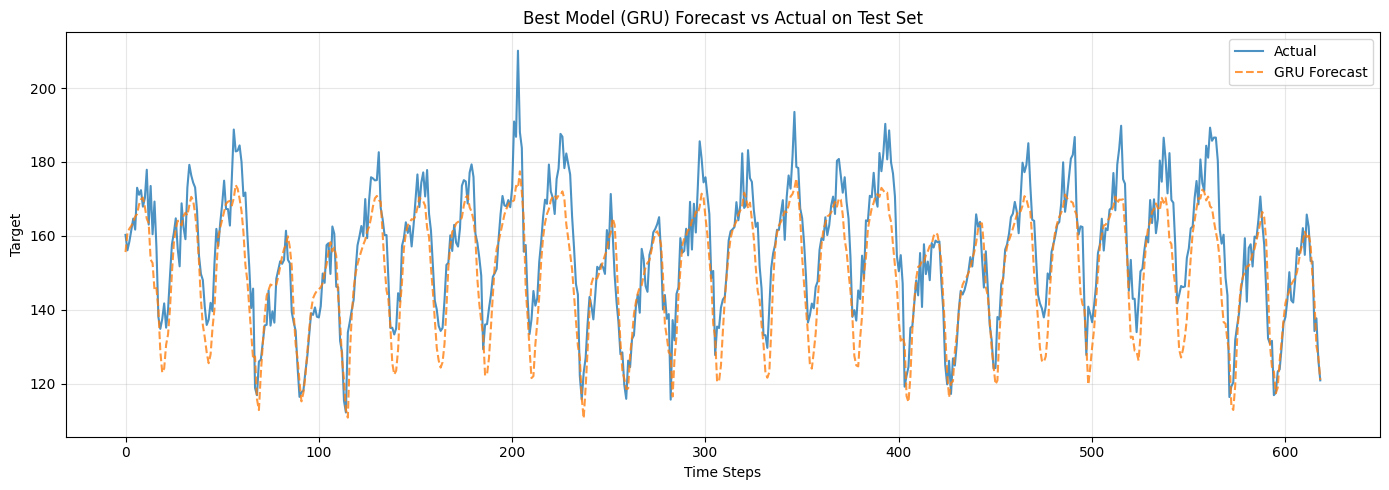

best_forecast_test.png сохранен в artifacts\figures\best_forecast_test.png


In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(range(len(test_true)), test_true, label='Actual', alpha=0.8, linewidth=1.5)
plt.plot(range(len(gru_test_pred)), gru_test_pred, label='GRU Forecast', alpha=0.8, linewidth=1.5, linestyle='--')
plt.xlabel('Time Steps')
plt.ylabel('Target')
plt.title('Best Model (GRU) Forecast vs Actual on Test Set')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "best_forecast_test.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"best_forecast_test.png сохранен в {FIGURES_DIR / 'best_forecast_test.png'}")

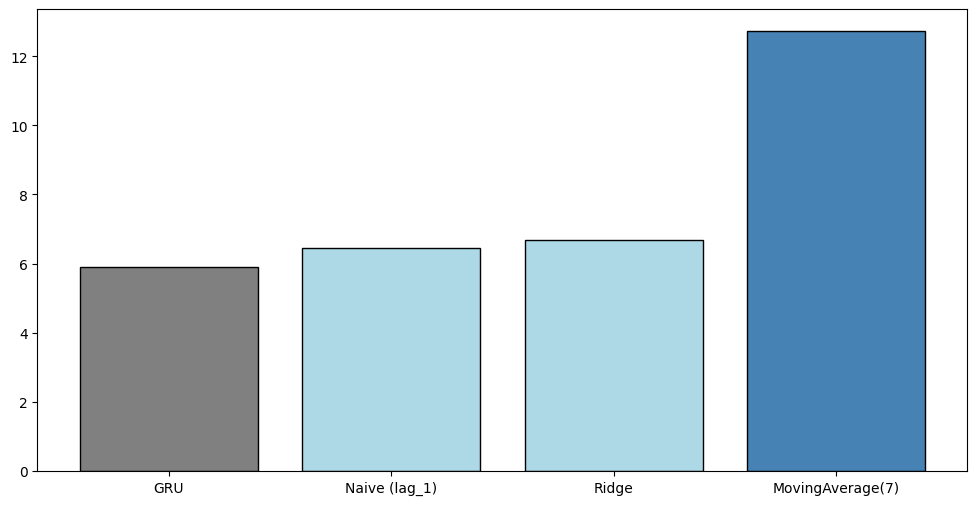

In [ ]:
plt.figure(figsize=(12, 6))
bars = plt.bar(val_results['model'], val_results['MAE'], 
               color=['gray', 'lightblue', 'lightblue', 'steelblue', 'darkgreen'], 
               edgecolor='black', linewidth=1)
plt.savefig(ARTIFACTS_DIR / "baselines_compare.png", dpi=150, bbox_inches='tight')
plt.show()